# EDA: Microsoft Cats vs Dogs

Разведывательный анализ датасета: баланс классов, размеры изображений, примеры.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.config import CLASS_NAMES, RAW_DIR
from src.dataset import load_splits

## 1. Баланс классов по сплитам

In [2]:
splits = load_splits()
rows = []
for split_name, files in splits.items():
    counts = Counter(Path(f).parent.name.lower() for f in files)
    rows.append((split_name, counts.get('cat', 0), counts.get('dog', 0), len(files)))

print(f"{'split':<8} {'cat':>6} {'dog':>6} {'total':>8}")
for split_name, c, d, t in rows:
    print(f"{split_name:<8} {c:>6} {d:>6} {t:>8}")

C:\Users\arion\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


split       cat    dog    total
train     10021   9977    19998
val        1244   1255     2499
test       1234   1267     2501


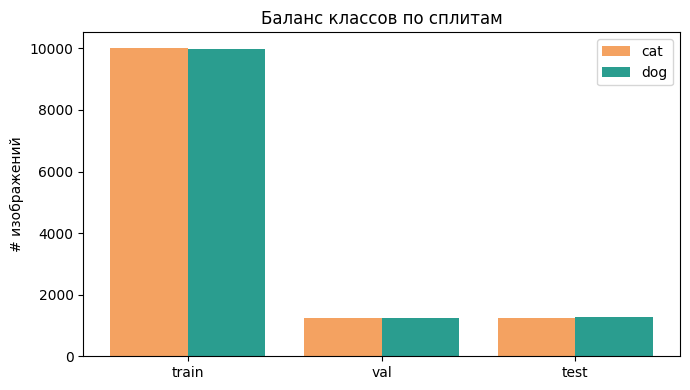

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(rows))
ax.bar(x - 0.2, [r[1] for r in rows], 0.4, label='cat', color='#f4a261')
ax.bar(x + 0.2, [r[2] for r in rows], 0.4, label='dog', color='#2a9d8f')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('# изображений'); ax.set_title('Баланс классов по сплитам'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Примеры из каждого класса

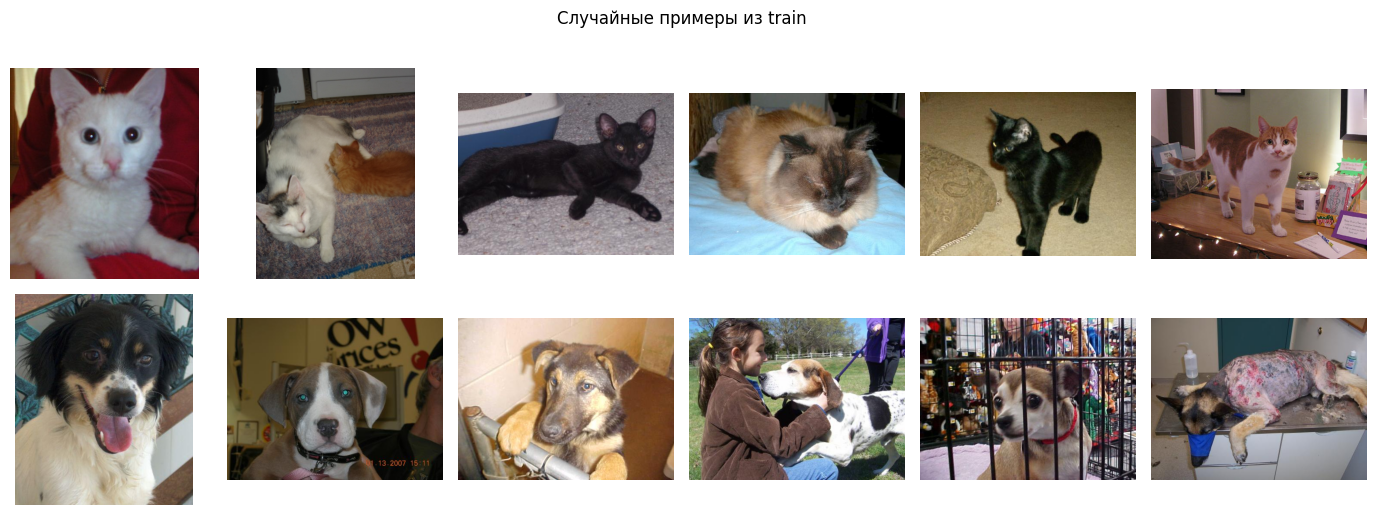

In [4]:
rng = random.Random(0)
train_by_cls = {cls: [f for f in splits['train'] if Path(f).parent.name.lower() == cls] for cls in CLASS_NAMES}

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, cls in enumerate(CLASS_NAMES):
    sample = rng.sample(train_by_cls[cls], 6)
    for col, rel in enumerate(sample):
        img = Image.open(RAW_DIR / rel).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=14)
plt.suptitle('Случайные примеры из train', y=1.02); plt.tight_layout(); plt.show()

## 3. Распределение размеров изображений

Берём подвыборку из train (полный проход по 20k+ файлам медленный).

In [5]:
rng = random.Random(42)
sample = rng.sample(splits['train'], min(1000, len(splits['train'])))
widths, heights, aspects = [], [], []
for rel in sample:
    with Image.open(RAW_DIR / rel) as im:
        w, h = im.size
    widths.append(w); heights.append(h); aspects.append(w / h)

print(f'width:  median={int(np.median(widths))}, min={min(widths)}, max={max(widths)}')
print(f'height: median={int(np.median(heights))}, min={min(heights)}, max={max(heights)}')
print(f'aspect (w/h): median={np.median(aspects):.2f}, min={min(aspects):.2f}, max={max(aspects):.2f}')

width:  median=461, min=60, max=500
height: median=375, min=55, max=500
aspect (w/h): median=1.25, min=0.46, max=2.98


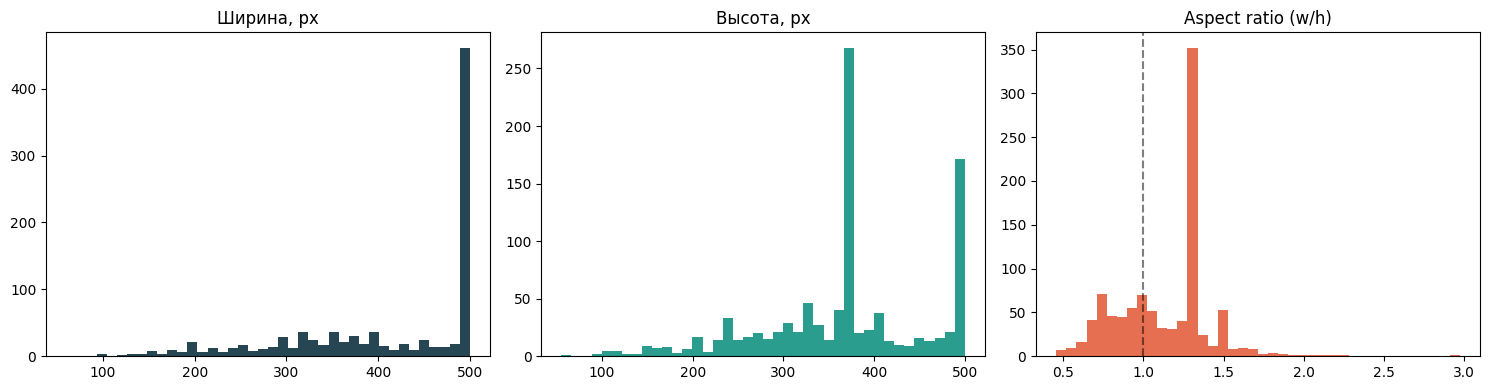

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=40, color='#264653'); axes[0].set_title('Ширина, px')
axes[1].hist(heights, bins=40, color='#2a9d8f'); axes[1].set_title('Высота, px')
axes[2].hist(aspects, bins=40, color='#e76f51'); axes[2].set_title('Aspect ratio (w/h)')
axes[2].axvline(1.0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## Выводы

- Классы сбалансированы (≈50/50 в каждом сплите) → accuracy — валидная метрика.
- Размеры сильно варьируются → `Resize(256) + CenterCrop(224)` оправдан.
- Aspect ratios ≈1 (квадратные), но есть выбросы — центральный кроп не обрежет критичные части животного в большинстве случаев.